# 🧑‍🏫 Aula 8 - Redução de Dimensionalidade: PCA e UMAP Aplicados a Vibração

---

## 📚 Sumário

1. [Contexto: De Onde Viemos e Para Onde Vamos](#1-contexto-de-onde-viemos-e-para-onde-vamos)
2. [Por Que Reduzir Dimensionalidade?](#2-por-que-reduzir-dimensionalidade)
3. [Carregamento dos Dados](#3-carregamento-dos-dados)
4. [PCA — Principal Component Analysis](#4-pca--principal-component-analysis)
   - 4.1 Fundamentos Matemáticos (Intuitivos)
   - 4.2 PCA nas 27 Features de Vibração
   - 4.3 Variância Explicada e Escolha de Componentes
   - 4.4 Loadings: O Que Cada Componente Captura?
   - 4.5 Reconstrução de Dados com PCA
5. [UMAP — Uniform Manifold Approximation and Projection](#5-umap--uniform-manifold-approximation-and-projection)
   - 5.1 Fundamentos do UMAP
   - 5.2 UMAP nas Features de Vibração
   - 5.3 Efeito dos Hiperparâmetros
6. [PCA vs. UMAP: Comparação Direta](#6-pca-vs-umap-comparação-direta)
7. [Redução de Dimensionalidade como Pré-Processamento](#7-redução-de-dimensionalidade-como-pré-processamento)
   - 7.1 Clustering com PCA Prévio
   - 7.2 Classificação com PCA Prévio
8. [Análise de Drift Temporal](#8-análise-de-drift-temporal)
9. [Aplicação nos Dados Brutos (ADXL345)](#9-aplicação-nos-dados-brutos-adxl345)
10. [Exportação dos Artefatos](#10-exportação-dos-artefatos)
11. [Importação e Predição em "Novo Sistema"](#11-importação-e-predição-em-novo-sistema)
12. [Resumo e Conclusões](#12-resumo-e-conclusões)

---

## 🎯 Capacidades Técnicas Trabalhadas

- **Utilizar adequadamente a redução de dimensionalidade** em reconhecimento de padrões.
- **Selecionar o método mais adequado** (PCA vs. UMAP) conforme o objetivo.
- **Aplicar redução como pré-processamento** para melhorar clustering e classificação.

## 🤝 Capacidades Socioemocionais Trabalhadas

- **Criatividade, originalidade e iniciativa** — explorar combinações de técnicas.
- **Pensamento analítico** — interpretar componentes abstratos e decidir quantos manter.

---

## 1. Contexto: De Onde Viemos e Para Onde Vamos

### 📖 Recapitulação do Nosso Pipeline

| Aula | O que fizemos | Resultado |
|------|--------------|-----------|
| **Aula 5** | Feature Engineering — 1082 leituras brutas → 32 janelas × 27 features | `vibration_features.csv` |
| **Aula 6** | Classificação Supervisionada — SVM, Random Forest, Logistic Regression | 3 modelos `.joblib` |
| **Aula 7** | Clustering Não Supervisionado — K-Means, DBSCAN, Hierárquico | Modelos de clustering + alertas |
| **Aula 8 (HOJE)** | Redução de Dimensionalidade — PCA e UMAP | Compressão, visualização, pré-processamento |
| **Aula 9** | Consolidação — Integração com SBC | Pipeline completo |

### 🔗 Conexão Direta com a Aula 7

Na Aula 7, precisamos **visualizar 27 features** em 2D. Usamos PCA como "truque de visualização", mas não explicamos como funciona. Vimos que:
- PCA com 2 componentes capturava apenas parte da variância
- O gráfico de variância explicada sugeria que poderíamos comprimir bastante
- Com features engenheiradas, os clusters ficavam mais claros no espaço reduzido

**Hoje** vamos responder as perguntas que ficaram abertas:
1. **Como o PCA decide** quais direções são mais importantes?
2. **Quantas componentes** devemos manter na prática?
3. **O UMAP é melhor** que PCA? Quando usar cada um?
4. **Podemos usar redução como pré-processamento** para melhorar clustering e classificação?

### 🤔 O Problema das Muitas Dimensões

Na Aula 5, criamos 27 features. Mas em projetos reais, podemos ter **centenas ou milhares** de features:
- Processamento de imagens: cada pixel é uma feature → 640×480 = 307.200 features!
- Processamento de texto: cada palavra do vocabulário → 50.000+ features
- Sensores industriais: dezenas de sensores × dezenas de janelamentos × dezenas de estatísticas

> **💡 Analogia:** Imagine descrever uma pessoa com 100 características. A maioria é redundante — se alguém é "alto", provavelmente também tem "braços compridos". A redução de dimensionalidade encontra essas redundâncias e cria um "resumo" mais compacto.

---

## 2. Por Que Reduzir Dimensionalidade?

### 🎯 Objetivos da Redução de Dimensionalidade

| Objetivo | Descrição | Exemplo no Nosso Projeto |
|----------|-----------|--------------------------|
| **Visualização** | Ver dados de alta dimensão em 2D/3D | Plotar 27 features em um scatter 2D |
| **Remoção de ruído** | Features ruidosas são atenuadas | Eliminar features pouco informativas |
| **Aceleração** | Menos features = treino mais rápido | K-Means em 5 componentes vs. 27 features |
| **Combate ao overfitting** | Menos features = menos risco de decorar | Classificação com poucos dados |
| **Descorelação** | Criar features ortogonais (independentes) | Evitar que RMS e Mean "contem a mesma coisa" |

### ⚠️ A Maldição da Dimensionalidade (Curse of Dimensionality)

Com muitas features e poucas amostras (nosso caso: 32 amostras × 27 features!):
- **Distâncias perdem significado** — em alta dimensão, todos os pontos ficam "igualmente longe" uns dos outros
- **Overfitting aumenta** — o modelo pode "decorar" os dados facilmente com tantas features
- **Mais dados são necessários** — a quantidade de dados cresce exponencialmente com as dimensões

> **💡 Regra prática:** Idealmente, ter pelo menos **10× mais amostras que features**. Temos 32 amostras e 27 features — situação crítica! Reduzir para 5–7 componentes ajuda muito.

### 📋 Taxonomia: Métodos Lineares vs. Não-Lineares

| Tipo | Método | Preserva | Ideal para | Limitação |
|------|--------|----------|------------|-----------|
| **Linear** | **PCA** | Variância global | Pré-processamento, descorelação | Não captura relações curvas |
| **Linear** | LDA | Separação entre classes | Classificação (precisa de rótulos!) | Supervisionado |
| **Não-linear** | **UMAP** | Vizinhança local | Visualização de clusters | Não é determinístico |
| **Não-linear** | t-SNE | Vizinhança local | Visualização | Lento, não generalizável |
| **Não-linear** | Autoencoders | Representação latente | Deep learning | Complexo, precisa de muitos dados |

Nesta aula, focaremos em **PCA** (linear) e **UMAP** (não-linear) — os dois mais úteis na prática.

In [1]:
!pip install umap-learn

Defaulting to user installation because normal site-packages is not writeable


DEPRECATION: Loading egg at c:\programdata\anaconda3\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 23.3 will enforce this behaviour change. A possible replacement is to use pip for package installation..


In [2]:
# ============================================================
# 3. Carregamento dos Dados e Bibliotecas
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                              classification_report, f1_score)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Tentar importar UMAP
try:
    import umap
    HAS_UMAP = True
    print("✅ UMAP disponível!")
except ImportError:
    HAS_UMAP = False
    print("⚠️ UMAP não encontrado. Instale com: pip install umap-learn")
    print("   As seções de UMAP serão puladas.")

# Configurações visuais (consistentes com aulas anteriores)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [14, 5]
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

COLORS = {'no': '#2ecc71', 'yes': '#e74c3c'}

print("✅ Bibliotecas carregadas com sucesso!")

✅ UMAP disponível!
✅ Bibliotecas carregadas com sucesso!


In [3]:
# --- 3. Carregar os dados ---

# Dataset de features engenheiradas (Aula 5) — foco principal desta aula
feat_path = Path("processed_data/vibration_features.csv")
df_feat = pd.read_csv(feat_path)

# Dataset bruto (para comparação na Seção 9)
raw_path = Path("Datasets/Vibrational Sensor Data for 3D Printer Monitering/ADXL345_SensorData.csv")
df_raw = pd.read_csv(raw_path)

# Separar features e rótulos
feature_cols = [c for c in df_feat.columns if c != 'label']
X_feat = df_feat[feature_cols].values
y_feat_text = df_feat['label'].values
y_feat_numeric = np.array([0 if y == 'no' else 1 for y in y_feat_text])

# Padronizar (essencial para PCA e UMAP!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_feat)

print("=" * 60)
print("📊 DADOS CARREGADOS")
print("=" * 60)
print(f"   Features engenheiradas: {X_scaled.shape[0]} amostras × {X_scaled.shape[1]} features")
print(f"   Features: {feature_cols}")
print(f"   Distribuição: no={np.sum(y_feat_numeric==0)}, yes={np.sum(y_feat_numeric==1)}")
print(f"\n   Dataset bruto: {df_raw.shape[0]} leituras × {df_raw.shape[1]} colunas")
print(f"\n⚠️  Ratio amostras/features = {X_scaled.shape[0]}/{X_scaled.shape[1]} = {X_scaled.shape[0]/X_scaled.shape[1]:.1f}")
print(f"   (Ideal seria ≥ 10. Temos apenas {X_scaled.shape[0]/X_scaled.shape[1]:.1f} — redução é muito importante!)")

📊 DADOS CARREGADOS
   Features engenheiradas: 32 amostras × 27 features
   Features: ['X_rms', 'X_mean', 'X_std', 'X_max', 'X_min', 'X_kurt', 'X_skew', 'Y_rms', 'Y_mean', 'Y_std', 'Y_max', 'Y_min', 'Y_kurt', 'Y_skew', 'Z_rms', 'Z_mean', 'Z_std', 'Z_max', 'Z_min', 'Z_kurt', 'Z_skew', 'X_fft_mean', 'X_fft_max', 'Y_fft_mean', 'Y_fft_max', 'Z_fft_mean', 'Z_fft_max']
   Distribuição: no=7, yes=25

   Dataset bruto: 1082 leituras × 4 colunas

⚠️  Ratio amostras/features = 32/27 = 1.2
   (Ideal seria ≥ 10. Temos apenas 1.2 — redução é muito importante!)


---

## 4. PCA — Principal Component Analysis

### 4.1 Fundamentos Matemáticos (Versão Intuitiva)

O PCA procura **novas direções** (componentes) nos dados que capturam a **maior variância possível**.

#### Passo a Passo do PCA:

1. **Centralizar os dados** (média = 0 por feature) — feito pelo StandardScaler
2. **Calcular a matriz de covariância** $\mathbf{C} = \frac{1}{n-1}\mathbf{X}^T\mathbf{X}$ — mede como cada par de features varia junto
3. **Calcular autovalores e autovetores** de $\mathbf{C}$ — os autovetores são as **direções**, os autovalores são a **variância** nessas direções
4. **Ordenar** por autovalor decrescente — PC1 captura mais variância que PC2, que captura mais que PC3...
5. **Projetar** os dados nas top-K direções — compressão!

> **💡 Analogia visual:** Imagine uma nuvem de pontos 3D com forma de charuto. Uma foto de frente mostra um círculo (pouca informação). Uma foto de lado mostra o charuto inteiro. O PCA encontra o ângulo da "melhor foto" — a direção de mais variância.

#### Propriedades Importantes:

| Propriedade | Significado |
|-------------|------------|
| **Componentes são ortogonais** | PC1 ⊥ PC2 ⊥ PC3... — zero correlação entre eles |
| **Variância é aditiva** | variância(PC1) + variância(PC2) + ... = variância total |
| **Transformação linear** | Fácil de inverter (reconstruir dados originais) |
| **Determinístico** | Mesmos dados → mesmo resultado sempre |
| **Não supervisionado** | Não usa rótulos — só olha para X |

In [4]:
# --- 4.2 PCA nas 27 Features de Vibração ---

# PCA completo (todas as componentes) para análise
pca_full = PCA()  # sem n_components = mantém todas
X_pca_full = pca_full.fit_transform(X_scaled)

print("📊 PCA Completo (27 componentes):")
print(f"   Variância explicada por cada componente:")
for i, (var, cumvar) in enumerate(zip(pca_full.explained_variance_ratio_, 
                                       np.cumsum(pca_full.explained_variance_ratio_))):
    bar = '█' * int(var * 100)
    print(f"   PC{i+1:2d}: {var:6.2%} | Acumulada: {cumvar:6.2%} | {bar}")

print(f"\n   Total em 2 componentes: {sum(pca_full.explained_variance_ratio_[:2]):.2%}")
print(f"   Total em 5 componentes: {sum(pca_full.explained_variance_ratio_[:5]):.2%}")
print(f"   Total em 10 componentes: {sum(pca_full.explained_variance_ratio_[:10]):.2%}")

📊 PCA Completo (27 componentes):
   Variância explicada por cada componente:
   PC 1: 34.13% | Acumulada: 34.13% | ██████████████████████████████████
   PC 2: 20.20% | Acumulada: 54.33% | ████████████████████
   PC 3: 10.71% | Acumulada: 65.04% | ██████████
   PC 4:  9.63% | Acumulada: 74.67% | █████████
   PC 5:  8.61% | Acumulada: 83.27% | ████████
   PC 6:  6.03% | Acumulada: 89.31% | ██████
   PC 7:  3.90% | Acumulada: 93.21% | ███
   PC 8:  2.69% | Acumulada: 95.90% | ██
   PC 9:  1.86% | Acumulada: 97.76% | █
   PC10:  0.92% | Acumulada: 98.68% | 
   PC11:  0.63% | Acumulada: 99.31% | 
   PC12:  0.38% | Acumulada: 99.68% | 
   PC13:  0.11% | Acumulada: 99.79% | 
   PC14:  0.08% | Acumulada: 99.87% | 
   PC15:  0.05% | Acumulada: 99.92% | 
   PC16:  0.05% | Acumulada: 99.97% | 
   PC17:  0.01% | Acumulada: 99.98% | 
   PC18:  0.01% | Acumulada: 99.99% | 
   PC19:  0.00% | Acumulada: 100.00% | 
   PC20:  0.00% | Acumulada: 100.00% | 
   PC21:  0.00% | Acumulada: 100.00% | 
   PC22:

### 4.3 Variância Explicada e Escolha de Componentes

A questão central do PCA é: **quantas componentes manter?**

Existem vários critérios:

| Critério | Regra | Quando usar |
|----------|-------|-------------|
| **95% da variância** | Manter componentes até acumular 95% | Pré-processamento geral |
| **Cotovelo no gráfico** | Procurar queda abrupta no scree plot | Análises exploratórias |
| **Autovalor > 1** (Kaiser) | Componente deve explicar mais que 1 feature original | Ciências sociais |
| **Validação cruzada** | Testar desempenho downstream com N componentes | Quando PCA alimenta um modelo |

> **💡 Para o nosso caso (32 amostras, 27 features):** O critério 95% é o mais comum e confiável. Porém, com tão poucas amostras, manter poucos componentes (5–7) também ajuda a combater overfitting.

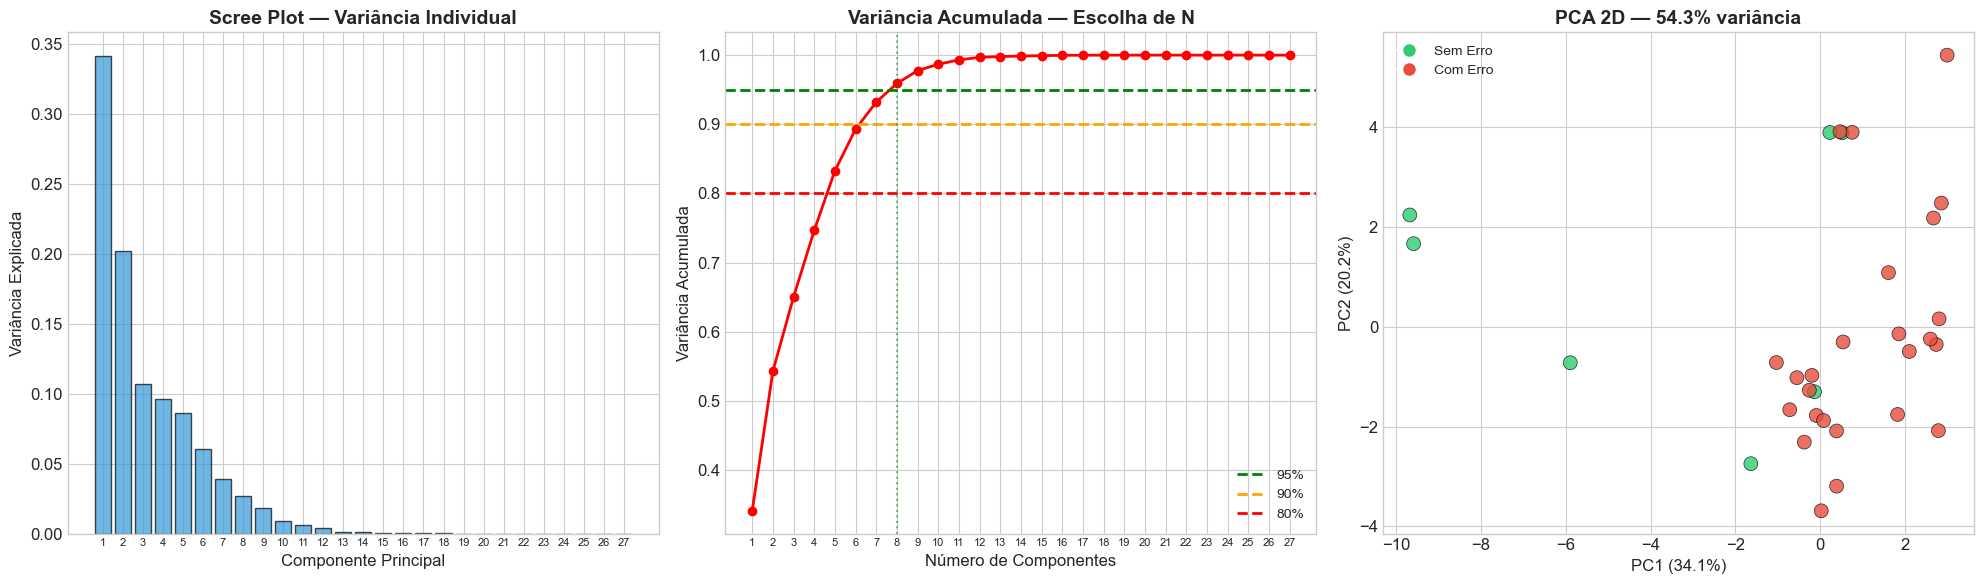

📊 Componentes necessários:
   Para 80% da variância: 5 componentes (compressão: 27D → 5D)
   Para 90% da variância: 7 componentes (compressão: 27D → 7D)
   Para 95% da variância: 8 componentes (compressão: 27D → 8D)

💡 Com apenas 2 componentes já vemos separação entre as classes!
   Mas perdemos 45.7% da informação.


In [5]:
# --- 4.3 Gráficos de Variância Explicada ---

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)
n_features = len(explained)

# Plot 1: Scree Plot (variância individual)
axes[0].bar(range(1, n_features+1), explained, color='#3498db', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Variância Explicada')
axes[0].set_title('Scree Plot — Variância Individual', fontweight='bold')
axes[0].set_xticks(range(1, n_features+1))
axes[0].tick_params(axis='x', labelsize=8)

# Plot 2: Variância Acumulada
axes[1].plot(range(1, n_features+1), cumulative, 'ro-', linewidth=2, markersize=6)
axes[1].axhline(y=0.95, color='green', linestyle='--', linewidth=2, label='95%')
axes[1].axhline(y=0.90, color='orange', linestyle='--', linewidth=2, label='90%')
axes[1].axhline(y=0.80, color='red', linestyle='--', linewidth=2, label='80%')

# Encontrar n_componentes para cada limiar
n_95 = np.argmax(cumulative >= 0.95) + 1
n_90 = np.argmax(cumulative >= 0.90) + 1
n_80 = np.argmax(cumulative >= 0.80) + 1

axes[1].axvline(x=n_95, color='green', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Variância Acumulada')
axes[1].set_title('Variância Acumulada — Escolha de N', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_xticks(range(1, n_features+1))
axes[1].tick_params(axis='x', labelsize=8)

# Plot 3: Scatter PCA 2D com rótulos
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

colors = ['#2ecc71' if y == 'no' else '#e74c3c' for y in y_feat_text]
axes[2].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=colors, s=100, alpha=0.8,
                edgecolors='black', linewidths=0.5)
axes[2].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
axes[2].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
axes[2].set_title(f'PCA 2D — {pca_2d.explained_variance_ratio_.sum():.1%} variância', fontweight='bold')

# Legenda manual
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=10, label='Sem Erro'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='Com Erro')
]
axes[2].legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.show()

print(f"📊 Componentes necessários:")
print(f"   Para 80% da variância: {n_80} componentes (compressão: {n_features}D → {n_80}D)")
print(f"   Para 90% da variância: {n_90} componentes (compressão: {n_features}D → {n_90}D)")
print(f"   Para 95% da variância: {n_95} componentes (compressão: {n_features}D → {n_95}D)")
print(f"\n💡 Com apenas 2 componentes já vemos separação entre as classes!")
print(f"   Mas perdemos {1 - pca_2d.explained_variance_ratio_.sum():.1%} da informação.")

### 4.4 Loadings: O Que Cada Componente Captura?

Os **loadings** (ou **pesos**) do PCA nos dizem **quais features originais contribuem mais** para cada componente principal. Isto é fundamental para **interpretar** o que o PCA "descobriu".

Por exemplo, se PC1 tem loadings altos para `Z_rms`, `Z_mean`, `Z_std`:
- Significa que PC1 captura principalmente a **variação no eixo Z**
- Faz sentido? Z é o eixo vertical — gravidade + vibração = alta variância!

> **💡 Os loadings são os autovetores** da matriz de covariância. Cada autovetor é uma "receita" que combina as features originais para criar uma componente.

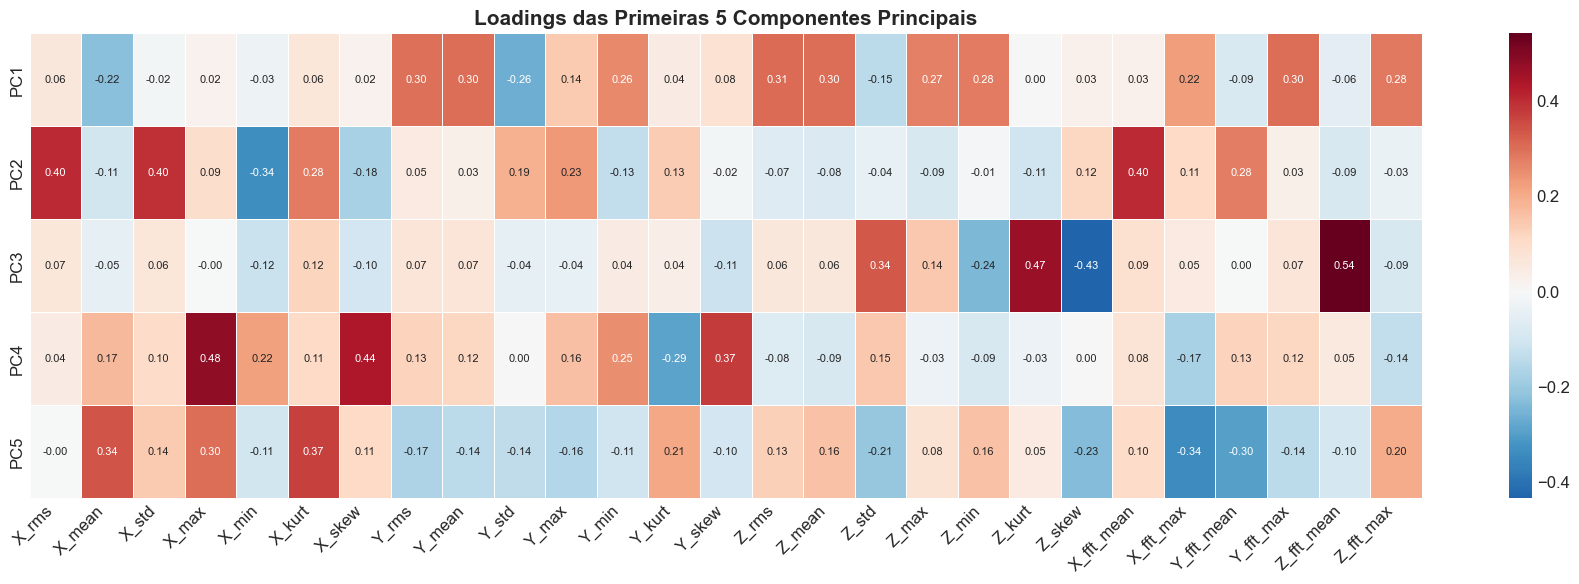

📊 Features mais importantes por componente:

   PC1 (34.1% variância):
     + Z_rms           (loading = +0.306)
     + Y_fft_max       (loading = +0.303)
     + Y_mean          (loading = +0.303)
     + Z_mean          (loading = +0.301)
     + Y_rms           (loading = +0.296)

   PC2 (20.2% variância):
     + X_rms           (loading = +0.403)
     + X_fft_mean      (loading = +0.402)
     + X_std           (loading = +0.396)
     - X_min           (loading = -0.337)
     + X_kurt          (loading = +0.279)

   PC3 (10.7% variância):
     + Z_fft_mean      (loading = +0.542)
     + Z_kurt          (loading = +0.466)
     - Z_skew          (loading = -0.434)
     + Z_std           (loading = +0.335)
     - Z_min           (loading = -0.240)

   PC4 (9.6% variância):
     + X_max           (loading = +0.479)
     + X_skew          (loading = +0.438)
     + Y_skew          (loading = +0.374)
     - Y_kurt          (loading = -0.292)
     + Y_min           (loading = +0.250)

   PC5 (

In [6]:
# --- 4.4 Loadings do PCA ---

# Heatmap dos loadings das primeiras 5 componentes
n_show = min(5, n_95)
loadings = pca_full.components_[:n_show]

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=feature_cols, yticklabels=[f'PC{i+1}' for i in range(n_show)],
            ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title(f'Loadings das Primeiras {n_show} Componentes Principais', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Top features por componente
print("📊 Features mais importantes por componente:")
for i in range(n_show):
    loading_abs = np.abs(pca_full.components_[i])
    top_indices = np.argsort(loading_abs)[::-1][:5]
    
    print(f"\n   PC{i+1} ({pca_full.explained_variance_ratio_[i]:.1%} variância):")
    for idx in top_indices:
        sign = '+' if pca_full.components_[i][idx] > 0 else '-'
        print(f"     {sign} {feature_cols[idx]:15s} (loading = {pca_full.components_[i][idx]:+.3f})")

print("\n💡 Interpretação dos Loadings:")
print("   • Valores altos (positivos ou negativos) = feature contribui muito")
print("   • Sinais opostos = features variam inversamente nessa componente")
print("   • Features do mesmo eixo (X, Y, Z) tendem a agrupar-se nas mesmas PCs")

### 4.5 Reconstrução de Dados com PCA

Uma propriedade poderosa do PCA é que podemos **reconstruir** os dados originais a partir dos componentes. Quanto mais componentes usarmos, mais fiel é a reconstrução.

$\hat{\mathbf{X}} = \mathbf{X}_{PCA} \cdot \mathbf{W}^T + \overline{\mathbf{X}}$

Onde $\mathbf{W}$ são os loadings (autovetores) e $\overline{\mathbf{X}}$ é a média original.

O **erro de reconstrução** é uma métrica importante:
- Baixo = mantivemos a informação essencial
- Alto = perdemos informação demais (poucas componentes)
- Pode ser usado para **detecção de anomalias**: dados muito diferentes do treino terão erro de reconstrução alto!

,n_componentes,variancia_explicada,mse_reconstrucao,compressao
0,1,0.3413,0.6587,27D → 1D
1,2,0.5433,0.4567,27D → 2D
2,3,0.6504,0.3496,27D → 3D
3,5,0.8327,0.1673,27D → 5D
4,7,0.9321,0.0679,27D → 7D
5,8,0.9590,0.0410,27D → 8D
6,27,1.0000,0.0000,27D → 27D


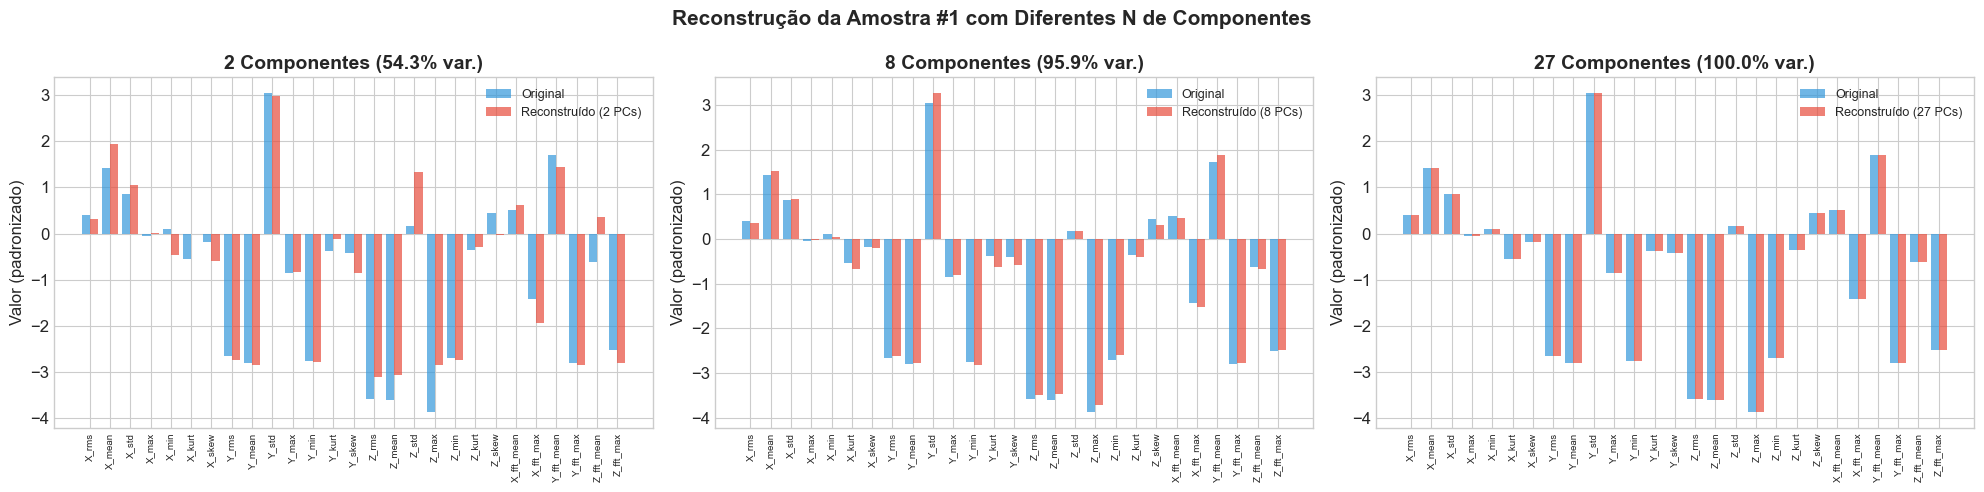

💡 Com poucas componentes, a reconstrução é grosseira (perde detalhes).
   Com todas as componentes, a reconstrução é perfeita (MSE ≈ 0).
   O ponto ideal está entre os dois extremos — manter a informação essencial.


In [7]:
# --- 4.5 Reconstrução com diferentes números de componentes ---

n_components_list = [1, 2, 3, 5, n_90, n_95, len(feature_cols)]
# Remover duplicatas e ordenar
n_components_list = sorted(set(n_components_list))

results_recon = []

for n_comp in n_components_list:
    pca_n = PCA(n_components=n_comp)
    X_reduced = pca_n.fit_transform(X_scaled)
    X_reconstructed = pca_n.inverse_transform(X_reduced)
    
    # Erro de reconstrução (MSE médio por amostra)
    mse = np.mean((X_scaled - X_reconstructed) ** 2)
    var_explained = sum(pca_n.explained_variance_ratio_)
    
    results_recon.append({
        'n_componentes': n_comp,
        'variancia_explicada': var_explained,
        'mse_reconstrucao': mse,
        'compressao': f'{len(feature_cols)}D → {n_comp}D'
    })

df_recon = pd.DataFrame(results_recon)
display(df_recon.round(4))

# Visualizar reconstrução de uma amostra específica
sample_idx = 0
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, n_comp in zip(axes, [2, n_95, len(feature_cols)]):
    pca_n = PCA(n_components=n_comp)
    X_red = pca_n.fit_transform(X_scaled)
    X_rec = pca_n.inverse_transform(X_red)
    
    x_pos = np.arange(len(feature_cols))
    ax.bar(x_pos - 0.2, X_scaled[sample_idx], 0.4, label='Original', color='#3498db', alpha=0.7)
    ax.bar(x_pos + 0.2, X_rec[sample_idx], 0.4, label=f'Reconstruído ({n_comp} PCs)', 
           color='#e74c3c', alpha=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(feature_cols, rotation=90, fontsize=7)
    ax.set_title(f'{n_comp} Componentes ({sum(pca_n.explained_variance_ratio_):.1%} var.)', 
                 fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylabel('Valor (padronizado)')

plt.suptitle(f'Reconstrução da Amostra #{sample_idx+1} com Diferentes N de Componentes', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 Com poucas componentes, a reconstrução é grosseira (perde detalhes).")
print("   Com todas as componentes, a reconstrução é perfeita (MSE ≈ 0).")
print("   O ponto ideal está entre os dois extremos — manter a informação essencial.")

---

## 5. UMAP — Uniform Manifold Approximation and Projection

### 5.1 Fundamentos do UMAP

O UMAP é uma técnica **não-linear** de redução de dimensionalidade, baseada em topologia e geometria diferencial. Na prática, o que precisamos saber:

#### Como Funciona (Intuitivo):

1. **Construir um grafo de vizinhança** — para cada ponto, encontra os K vizinhos mais próximos no espaço original
2. **Atribuir pesos** — vizinhos mais próximos recebem peso maior
3. **Otimizar um layout 2D/3D** — posiciona os pontos no espaço reduzido tentando preservar as distâncias de vizinhança

> **💡 Analogia:** Imagine uma folha de papel amassada em uma bola (dados em alta dimensão). O UMAP "desamassa" a folha, preservando as distâncias locais — pontos que estavam perto na bola ficam perto na folha plana.

#### Hiperparâmetros Principais:

| Parâmetro | Default | Efeito |
|-----------|---------|--------|
| `n_neighbors` | 15 | **Mais importante!** Poucos = foco local (clusters pequenos), Muitos = visão global (como PCA) |
| `min_dist` | 0.1 | Quão compactos são os clusters. 0 = muito compacto, 1 = espalhado |
| `n_components` | 2 | Dimensão do espaço reduzido |
| `metric` | euclidean | Distância usada (euclidean, cosine, manhattan...) |
| `random_state` | None | Semente para reprodutibilidade (UMAP é estocástico!) |

#### PCA vs. UMAP — Quando Usar Cada Um:

| Aspecto | PCA | UMAP |
|---------|-----|------|
| **Tipo** | Linear | Não-linear |
| **Determinístico** | ✅ Sim | ❌ Não (varia com random_state) |
| **Velocidade** | Muito rápido | Mais lento |
| **Inversível** | ✅ Sim (inverse_transform) | ❌ Difícil |
| **Preserva** | Variância global | Estrutura local |
| **Ideal para** | Pré-processamento, pipeline | Visualização, exploração |
| **N componentes** | Qualquer N | Geralmente 2 ou 3 |

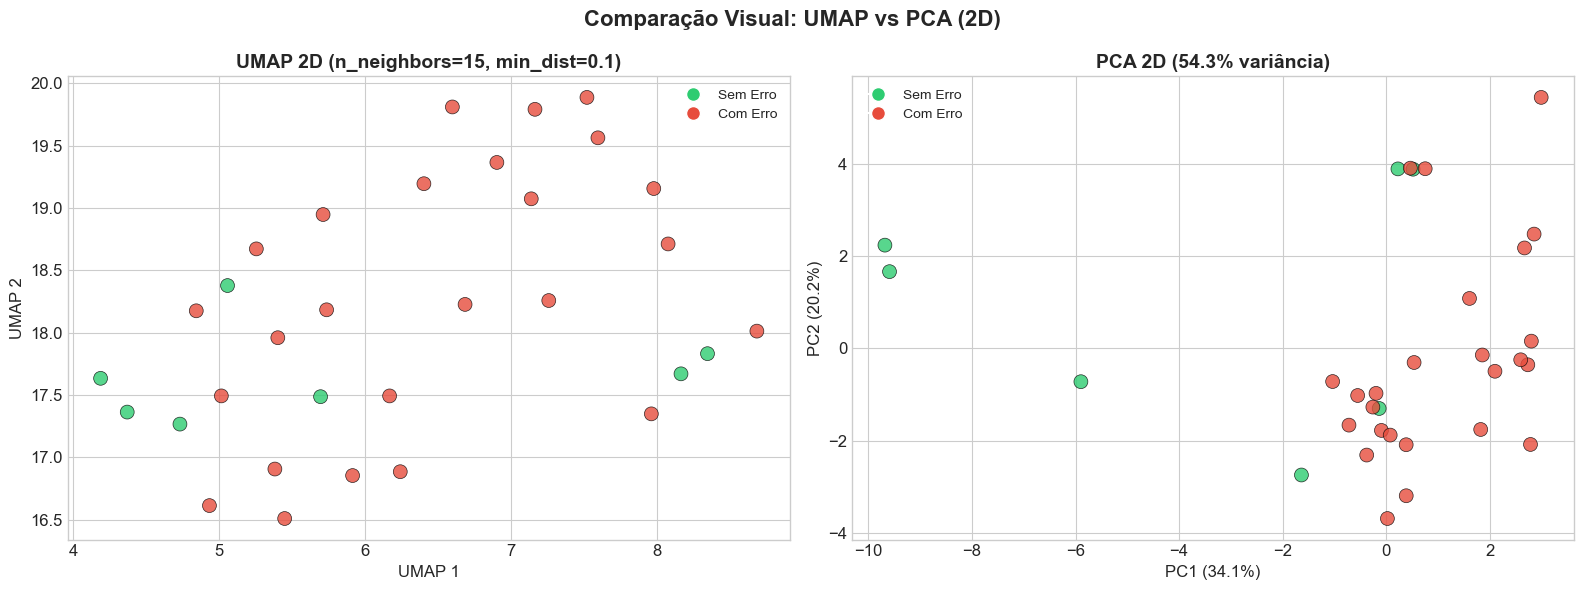

💡 Observações:
   • UMAP tende a criar clusters mais compactos e separados
   • PCA preserva distâncias globais — pontos distantes permanecem distantes
   • UMAP é melhor para VISUALIZAÇÃO de clusters
   • PCA é melhor para PRÉ-PROCESSAMENTO (determinístico, inversível)


In [8]:
# --- 5.2 UMAP nas Features de Vibração ---

if HAS_UMAP:
    # UMAP com parâmetros padrão
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    X_umap_2d = reducer.fit_transform(X_scaled)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: UMAP 2D
    colors = [COLORS[y] for y in y_feat_text]
    axes[0].scatter(X_umap_2d[:, 0], X_umap_2d[:, 1], c=colors, s=100, alpha=0.8,
                    edgecolors='black', linewidths=0.5)
    axes[0].set_xlabel('UMAP 1')
    axes[0].set_ylabel('UMAP 2')
    axes[0].set_title('UMAP 2D (n_neighbors=15, min_dist=0.1)', fontweight='bold')
    
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS['no'], markersize=10, label='Sem Erro'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS['yes'], markersize=10, label='Com Erro')
    ]
    axes[0].legend(handles=legend_elements, fontsize=10)
    
    # Plot 2: PCA 2D para comparação lado a lado
    axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=colors, s=100, alpha=0.8,
                    edgecolors='black', linewidths=0.5)
    axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
    axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
    axes[1].set_title(f'PCA 2D ({pca_2d.explained_variance_ratio_.sum():.1%} variância)', fontweight='bold')
    axes[1].legend(handles=legend_elements, fontsize=10)
    
    plt.suptitle('Comparação Visual: UMAP vs PCA (2D)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("💡 Observações:")
    print("   • UMAP tende a criar clusters mais compactos e separados")
    print("   • PCA preserva distâncias globais — pontos distantes permanecem distantes")
    print("   • UMAP é melhor para VISUALIZAÇÃO de clusters")
    print("   • PCA é melhor para PRÉ-PROCESSAMENTO (determinístico, inversível)")
else:
    print("⚠️ UMAP não disponível. Instale com: pip install umap-learn")
    print("   Pulando esta seção.")

### 5.3 Efeito dos Hiperparâmetros no UMAP

O UMAP é **muito sensível** aos hiperparâmetros. Vamos explorar visualmente o impacto de `n_neighbors` e `min_dist`:

- **`n_neighbors` baixo** (5): Foco em estrutura local → muitos clusterzinhos
- **`n_neighbors` alto** (30): Visão mais global → clusters maiores, mais parecido com PCA
- **`min_dist` baixo** (0.0): Pontos dentro de clusters ficam muito juntos
- **`min_dist` alto** (0.5): Pontos ficam mais espalhados, menos clusters evidentes

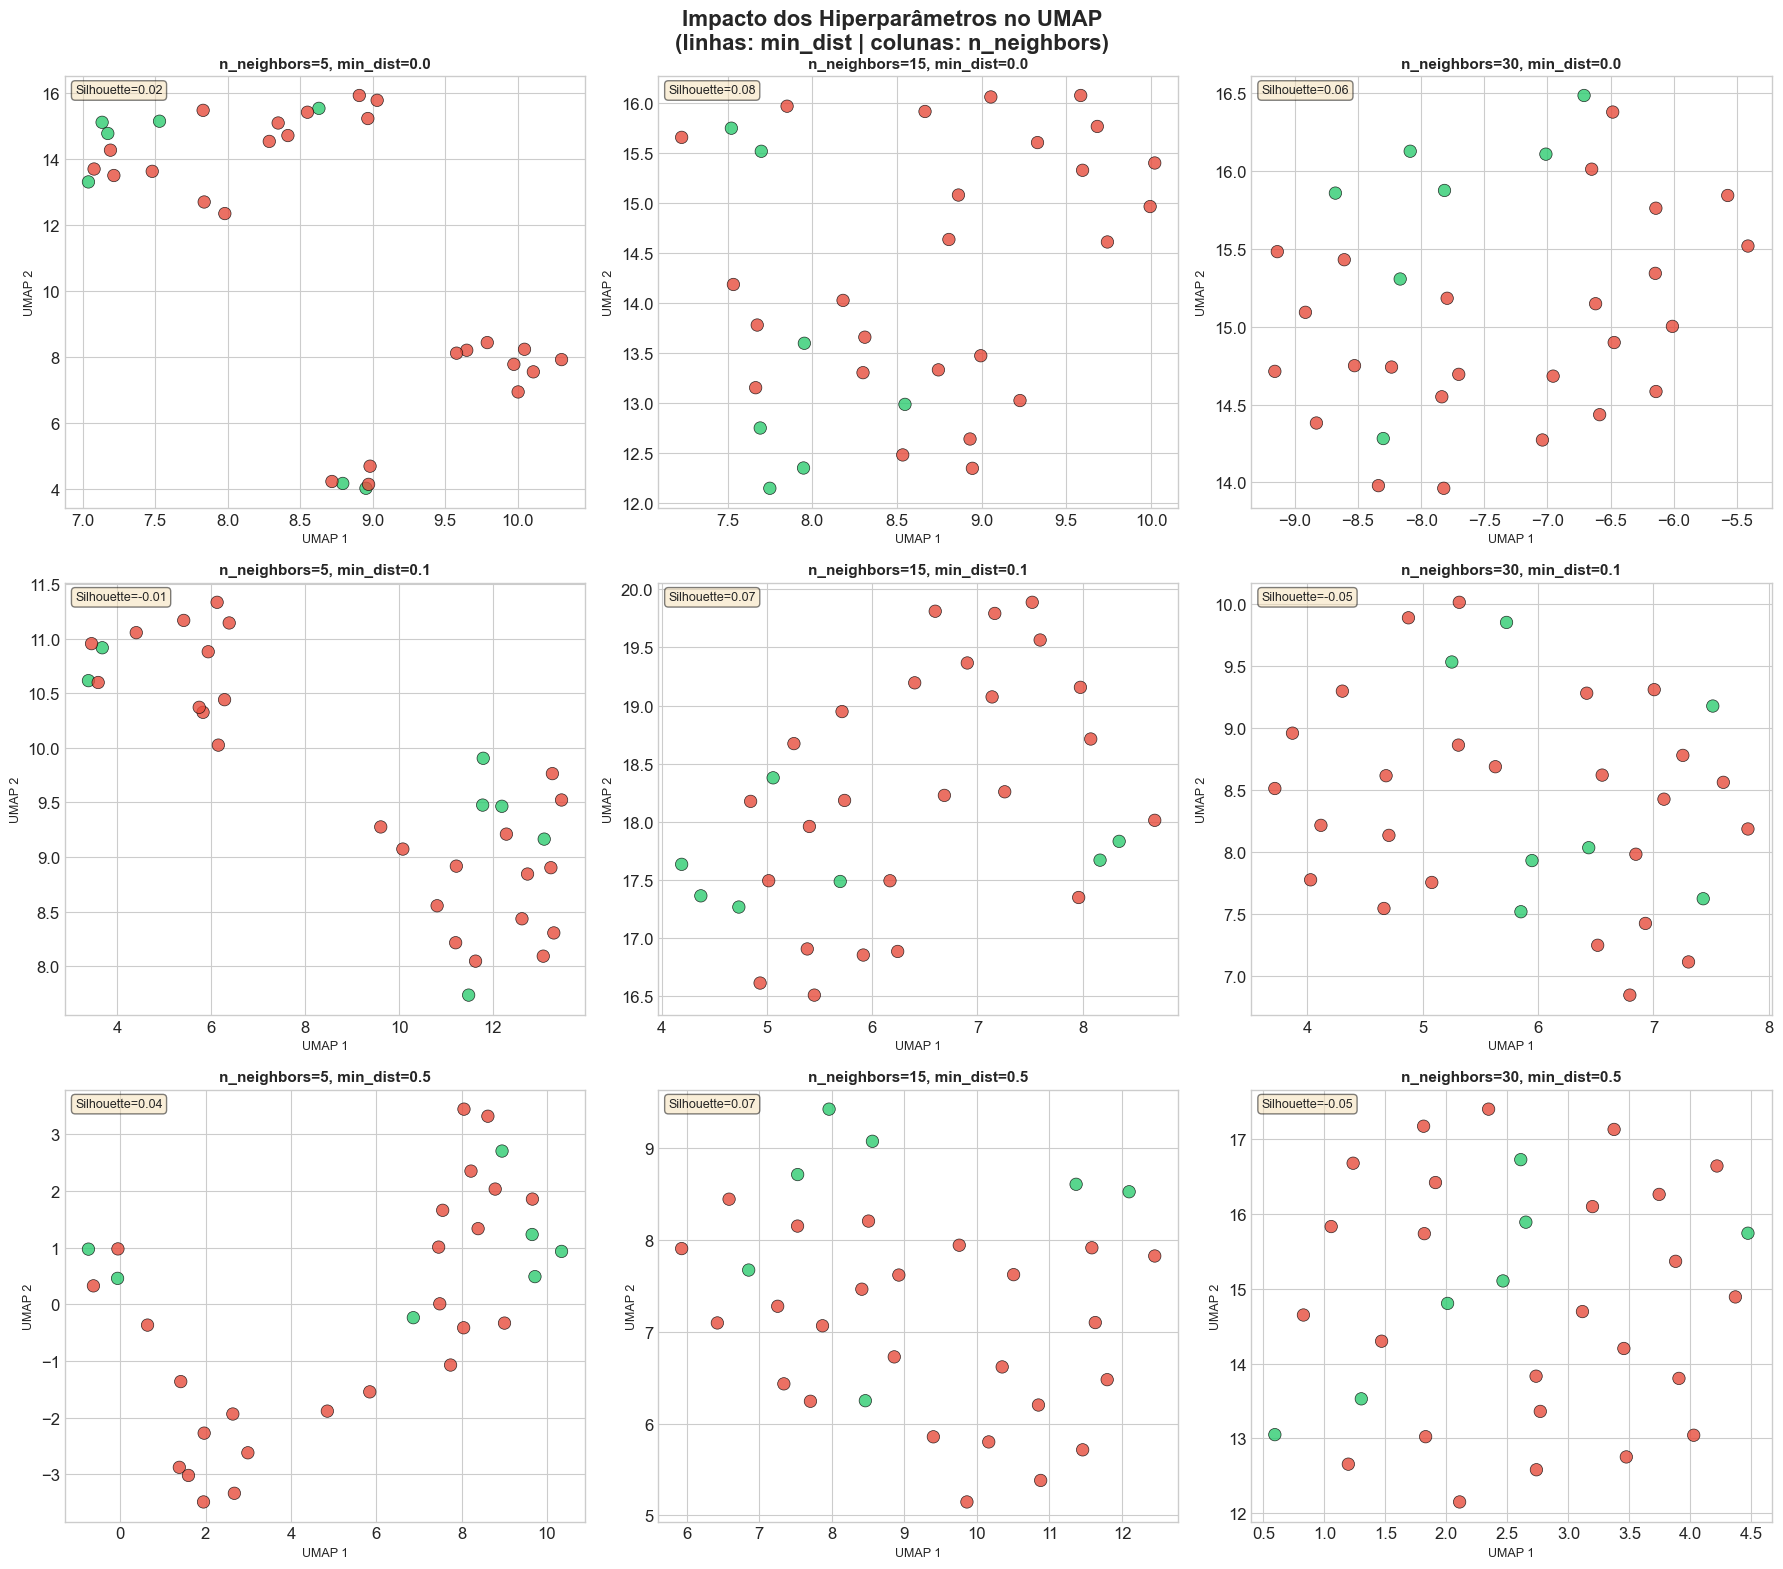

💡 Observações sobre os hiperparâmetros:
   • n_neighbors BAIXO → clusters mais fragmentados (foco local)
   • n_neighbors ALTO → layout mais contínuo (foco global)
   • min_dist BAIXO → pontos dentro do cluster ficam comprimidos
   • min_dist ALTO → distribuição mais uniforme, menos clusters evidentes
   • Silhouette Score indica separação entre classes no espaço reduzido


In [9]:
# --- 5.3 Exploração de Hiperparâmetros UMAP ---

if HAS_UMAP:
    n_neighbors_list = [5, 15, 30]
    min_dist_list = [0.0, 0.1, 0.5]
    
    fig, axes = plt.subplots(len(min_dist_list), len(n_neighbors_list), figsize=(18, 16))
    colors = [COLORS[y] for y in y_feat_text]
    
    for i, md in enumerate(min_dist_list):
        for j, nn in enumerate(n_neighbors_list):
            ax = axes[i][j]
            reducer = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=md, random_state=42)
            X_umap = reducer.fit_transform(X_scaled)
            
            ax.scatter(X_umap[:, 0], X_umap[:, 1], c=colors, s=80, alpha=0.8,
                      edgecolors='black', linewidths=0.5)
            ax.set_title(f'n_neighbors={nn}, min_dist={md}', fontweight='bold', fontsize=11)
            ax.set_xlabel('UMAP 1', fontsize=9)
            ax.set_ylabel('UMAP 2', fontsize=9)
            
            # Silhouette score como métrica de separação
            if len(np.unique(y_feat_numeric)) > 1:
                sil = silhouette_score(X_umap, y_feat_numeric)
                ax.text(0.02, 0.98, f'Silhouette={sil:.2f}', transform=ax.transAxes,
                       fontsize=9, va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('Impacto dos Hiperparâmetros no UMAP\n(linhas: min_dist | colunas: n_neighbors)', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("💡 Observações sobre os hiperparâmetros:")
    print("   • n_neighbors BAIXO → clusters mais fragmentados (foco local)")
    print("   • n_neighbors ALTO → layout mais contínuo (foco global)")
    print("   • min_dist BAIXO → pontos dentro do cluster ficam comprimidos")
    print("   • min_dist ALTO → distribuição mais uniforme, menos clusters evidentes")
    print("   • Silhouette Score indica separação entre classes no espaço reduzido")
else:
    print("⚠️ UMAP não disponível. Pulando exploração de hiperparâmetros.")

---

## 6. PCA vs. UMAP: Comparação Quantitativa

Já vimos as diferenças visuais. Agora vamos comparar **quantitativamente** usando:

1. **Preservação de vizinhança** — Os K vizinhos mais próximos no espaço original continuam próximos no espaço reduzido?
2. **Silhouette Score** — Quão bem separadas estão as classes no espaço reduzido?
3. **Trustworthiness** — Medida formal de preservação de estrutura local (sklearn)

Estas métricas nos ajudam a decidir **qual método usar para cada objetivo**.

In [10]:
# --- 6. Comparação Quantitativa PCA vs UMAP ---

from sklearn.manifold import trustworthiness
from sklearn.neighbors import NearestNeighbors

def preservacao_vizinhanca(X_orig, X_red, k=5):
    """Calcula a proporção de K vizinhos preservados após redução."""
    nn_orig = NearestNeighbors(n_neighbors=k+1).fit(X_orig)
    nn_red = NearestNeighbors(n_neighbors=k+1).fit(X_red)
    
    _, idx_orig = nn_orig.kneighbors(X_orig)
    _, idx_red = nn_red.kneighbors(X_red)
    
    # Excluir o próprio ponto (índice 0)
    idx_orig = idx_orig[:, 1:]
    idx_red = idx_red[:, 1:]
    
    preservacao_total = 0
    for i in range(len(X_orig)):
        vizinhos_comuns = len(set(idx_orig[i]) & set(idx_red[i]))
        preservacao_total += vizinhos_comuns / k
    
    return preservacao_total / len(X_orig)

# Comparar métodos
comparacao = []

# PCA com diferentes números de componentes
for n_comp in [2, 3, 5, n_95]:
    pca_n = PCA(n_components=n_comp)
    X_red = pca_n.fit_transform(X_scaled)
    
    entry = {
        'Método': f'PCA ({n_comp}D)',
        'Silhouette': silhouette_score(X_red, y_feat_numeric) if n_comp >= 2 else np.nan,
        'Trustworthiness': trustworthiness(X_scaled, X_red, n_neighbors=5),
        'Preserv. Vizinhança (k=5)': preservacao_vizinhanca(X_scaled, X_red, k=5),
        'Variância Explicada': sum(pca_n.explained_variance_ratio_)
    }
    comparacao.append(entry)

# UMAP (se disponível)
if HAS_UMAP:
    for nn in [10, 15, 30]:
        reducer = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=0.1, random_state=42)
        X_red = reducer.fit_transform(X_scaled)
        
        entry = {
            'Método': f'UMAP (nn={nn})',
            'Silhouette': silhouette_score(X_red, y_feat_numeric),
            'Trustworthiness': trustworthiness(X_scaled, X_red, n_neighbors=5),
            'Preserv. Vizinhança (k=5)': preservacao_vizinhanca(X_scaled, X_red, k=5),
            'Variância Explicada': np.nan  # UMAP não define variância explicada
        }
        comparacao.append(entry)

df_comp = pd.DataFrame(comparacao)
display(df_comp.round(3))

# Recomendação
print("\n📊 Interpretação:")
print("   • Silhouette → Separação entre classes (quanto maior, melhor)")
print("   • Trustworthiness → Preservação de vizinhança local (0 a 1, ideal = 1)")
print("   • Preservação de Vizinhança → Proporção de vizinhos mantidos")
print("   • Variância Explicada → Proporção da informação original retida (só PCA)")
print("\n💡 Conclusão prática:")
print("   • Para VISUALIZAÇÃO: usar UMAP (melhor separação visual)")
print("   • Para PRÉ-PROCESSAMENTO: usar PCA (determinístico, inversível, mais robusto)")

,Método,Silhouette,Trustworthiness,Preserv. Vizinhança (k=5),Variância Explicada
0,PCA (2D),0.365,0.891,0.663,0.543
1,PCA (3D),0.401,0.918,0.713,0.650
2,PCA (5D),0.319,0.962,0.831,0.833
3,PCA (8D),0.286,0.995,0.900,0.959
4,UMAP (nn=10),0.047,0.871,0.669,NaN
5,UMAP (nn=15),0.065,0.848,0.625,NaN
6,UMAP (nn=30),-0.050,0.794,0.581,NaN



📊 Interpretação:
   • Silhouette → Separação entre classes (quanto maior, melhor)
   • Trustworthiness → Preservação de vizinhança local (0 a 1, ideal = 1)
   • Preservação de Vizinhança → Proporção de vizinhos mantidos
   • Variância Explicada → Proporção da informação original retida (só PCA)

💡 Conclusão prática:
   • Para VISUALIZAÇÃO: usar UMAP (melhor separação visual)
   • Para PRÉ-PROCESSAMENTO: usar PCA (determinístico, inversível, mais robusto)


---

## 7. Redução de Dimensionalidade como Pré-Processamento

Esta é uma das aplicações **mais importantes** da redução de dimensionalidade no mundo real. Em vez de usar PCA apenas para visualização, usamos como **etapa do pipeline** antes de clustering ou classificação.

### 7.1 Clustering com PCA Prévio

Na Aula 7, aplicamos K-Means diretamente em 27 features. Agora vamos comparar:
- K-Means em **27 features originais** (padronizadas)
- K-Means em **PCA com N componentes** (variando N)

**Hipótese:** Reduzir dimensionalidade antes do clustering pode **melhorar** os resultados ao remover ruído e features redundantes.

### 7.2 Classificação com PCA Prévio

Na Aula 6, treinamos SVM, RF e LR em 27 features. Será que PCA antes melhora ou piora?

**Hipótese:** Com apenas 32 amostras e 27 features, PCA deve **ajudar** ao combater overfitting.

,Espaço,Silhouette,ARI (vs. rótulos)
0,Original (27D),0.477,0.442
1,"PCA (2D, 54% var.)",0.646,0.442
2,"PCA (3D, 65% var.)",0.609,0.442
3,"PCA (5D, 83% var.)",0.535,0.442
4,"PCA (7D, 93% var.)",0.507,0.442
5,"PCA (8D, 96% var.)",0.496,0.442


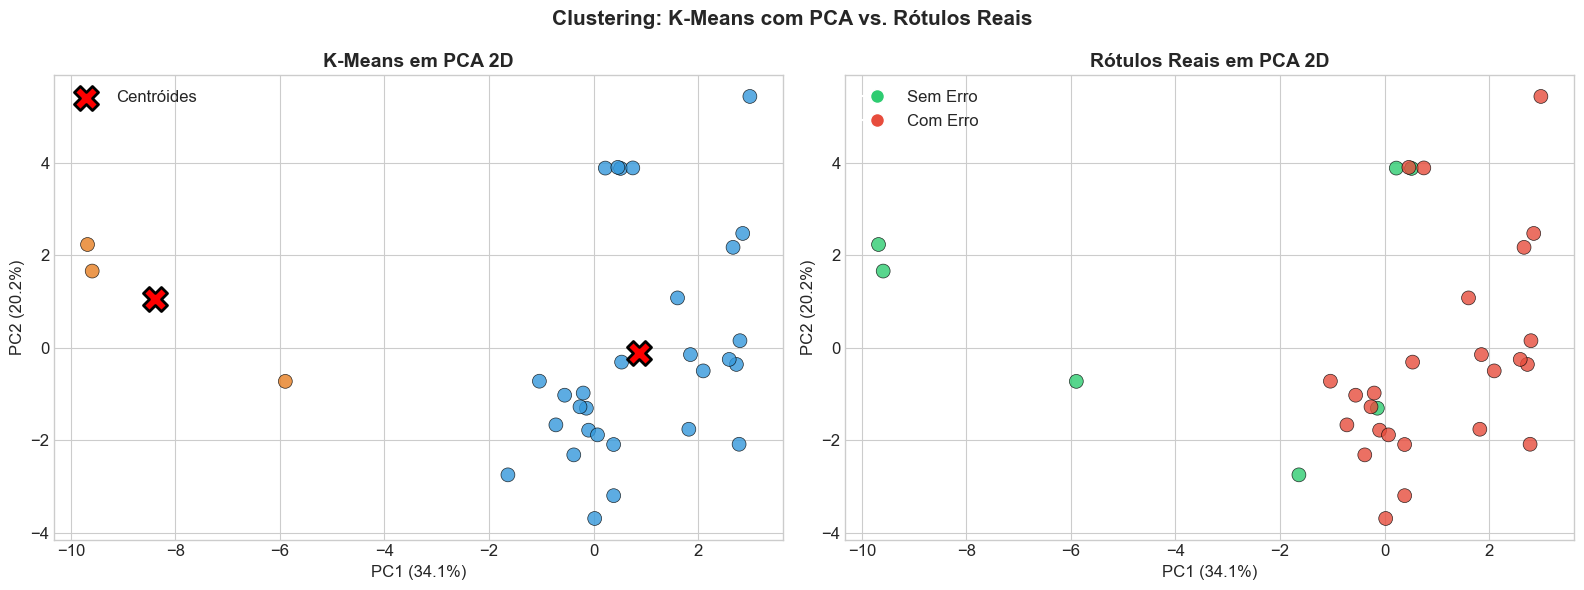

💡 ARI (Adjusted Rand Index): Quanto maior (perto de 1), melhor a concordância com os rótulos reais.
   ARI = 0 → clusters aleatórios | ARI = 1 → clusters perfeitos


In [11]:
# --- 7.1 Clustering com PCA Prévio ---

# Comparar K-Means em diferentes espaços
n_clusters = 2  # sem erro vs. com erro

cluster_results = []

# 1) K-Means no espaço original (27D)
km_orig = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels_orig = km_orig.fit_predict(X_scaled)
sil_orig = silhouette_score(X_scaled, labels_orig)
ari_orig = adjusted_rand_score(y_feat_numeric, labels_orig)
cluster_results.append({'Espaço': 'Original (27D)', 'Silhouette': sil_orig, 
                         'ARI (vs. rótulos)': ari_orig})

# 2) K-Means com PCA (vários N)
for n_comp in [2, 3, 5, n_90, n_95]:
    pca_n = PCA(n_components=n_comp)
    X_pca_n = pca_n.fit_transform(X_scaled)
    
    km_pca = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels_pca = km_pca.fit_predict(X_pca_n)
    sil_pca = silhouette_score(X_pca_n, labels_pca)
    ari_pca = adjusted_rand_score(y_feat_numeric, labels_pca)
    var_exp = sum(pca_n.explained_variance_ratio_)
    
    cluster_results.append({'Espaço': f'PCA ({n_comp}D, {var_exp:.0%} var.)', 
                             'Silhouette': sil_pca, 'ARI (vs. rótulos)': ari_pca})

df_cluster = pd.DataFrame(cluster_results)
display(df_cluster.round(3))

# Visualizar K-Means em PCA 2D vs original projetado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means em PCA 2D
km_2d = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels_2d = km_2d.fit_predict(X_pca_2d)
scatter_colors = ['#3498db' if l == 0 else '#e67e22' for l in labels_2d]
axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=scatter_colors, s=100, alpha=0.8,
                edgecolors='black', linewidths=0.5)
axes[0].scatter(km_2d.cluster_centers_[:, 0], km_2d.cluster_centers_[:, 1],
                c='red', marker='X', s=300, edgecolors='black', linewidths=2, label='Centróides')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('K-Means em PCA 2D', fontweight='bold')
axes[0].legend()

# Rótulos reais para comparação
colors_real = [COLORS[y] for y in y_feat_text]
axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=colors_real, s=100, alpha=0.8,
                edgecolors='black', linewidths=0.5)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('Rótulos Reais em PCA 2D', fontweight='bold')
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS['no'], markersize=10, label='Sem Erro'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS['yes'], markersize=10, label='Com Erro')
]
axes[1].legend(handles=legend_elements)

plt.suptitle('Clustering: K-Means com PCA vs. Rótulos Reais', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 ARI (Adjusted Rand Index): Quanto maior (perto de 1), melhor a concordância com os rótulos reais.")
print("   ARI = 0 → clusters aleatórios | ARI = 1 → clusters perfeitos")

📊 F1-Score Médio (Cross-Validation 5-Fold):


Espaço,Original (27D),"PCA (2D, 54%)","PCA (5D, 83%)","PCA (8D, 96%)"
Classificador,,,,
Logistic Regression,0.886,0.908,0.901,0.886
Random Forest,0.864,0.864,0.814,0.835
SVM (RBF),0.857,0.857,0.879,0.835


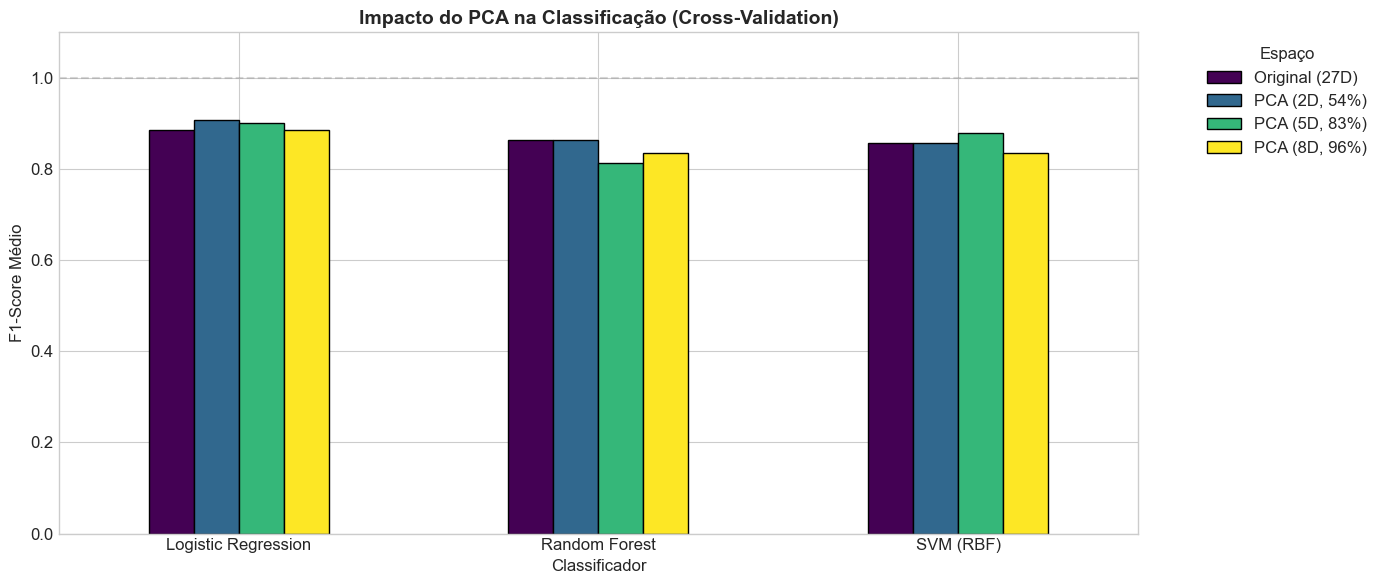

💡 Observações:
   • Com poucas amostras (32), reduzir dimensionalidade pode melhorar classificação
   • O número ideal de componentes varia por classificador
   • PCA antes de classificação = pipeline mais robusto e menos propenso a overfitting


In [12]:
# --- 7.2 Classificação com PCA Prévio ---

# Comparar desempenho de classificação com e sem PCA
classifiers = {
    'SVM (RBF)': SVC(kernel='rbf', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
classif_results = []

# Para cada classificador
for clf_name, clf in classifiers.items():
    # Sem PCA (27D original)
    scores_orig = cross_val_score(clf, X_scaled, y_feat_numeric, cv=cv, scoring='f1')
    classif_results.append({
        'Classificador': clf_name,
        'Espaço': 'Original (27D)',
        'F1 Médio': scores_orig.mean(),
        'F1 Std': scores_orig.std()
    })
    
    # Com PCA (vários N)
    for n_comp in [2, 5, n_95]:
        pca_n = PCA(n_components=n_comp)
        X_pca_n = pca_n.fit_transform(X_scaled)
        var_exp = sum(pca_n.explained_variance_ratio_)
        
        scores_pca = cross_val_score(clf, X_pca_n, y_feat_numeric, cv=cv, scoring='f1')
        classif_results.append({
            'Classificador': clf_name,
            'Espaço': f'PCA ({n_comp}D, {var_exp:.0%})',
            'F1 Médio': scores_pca.mean(),
            'F1 Std': scores_pca.std()
        })

df_classif = pd.DataFrame(classif_results)

# Pivot table para melhor visualização
pivot = df_classif.pivot_table(index='Classificador', columns='Espaço', values='F1 Médio')
print("📊 F1-Score Médio (Cross-Validation 5-Fold):")
display(pivot.round(3))

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(14, 6))
pivot.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='black')
ax.set_ylabel('F1-Score Médio')
ax.set_title('Impacto do PCA na Classificação (Cross-Validation)', fontweight='bold', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Espaço', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 Observações:")
print("   • Com poucas amostras (32), reduzir dimensionalidade pode melhorar classificação")
print("   • O número ideal de componentes varia por classificador")
print("   • PCA antes de classificação = pipeline mais robusto e menos propenso a overfitting")

---

## 8. Análise de Drift Temporal com PCA

### Conceito de Drift

Em produção, os dados mudam ao longo do tempo — sensores degradam, condições ambientais mudam, processos industriais variam. O **drift** é essa mudança gradual na distribuição dos dados.

O PCA oferece uma forma elegante de **detectar drift**:
1. Treinar PCA nos dados "normais" (referência)
2. Projetar novos dados no mesmo espaço PCA
3. Se a projeção se deslocar significativamente → **drift detectado**

> **💡 No nosso caso:** Vamos simular drift temporal dividindo os dados em janelas e observando se a distribuição no espaço PCA muda. Também vamos monitorar o **erro de reconstrução** como indicador de anomalia.

ℹ️ n_95=8, max permitido=7 → usando n_components=7


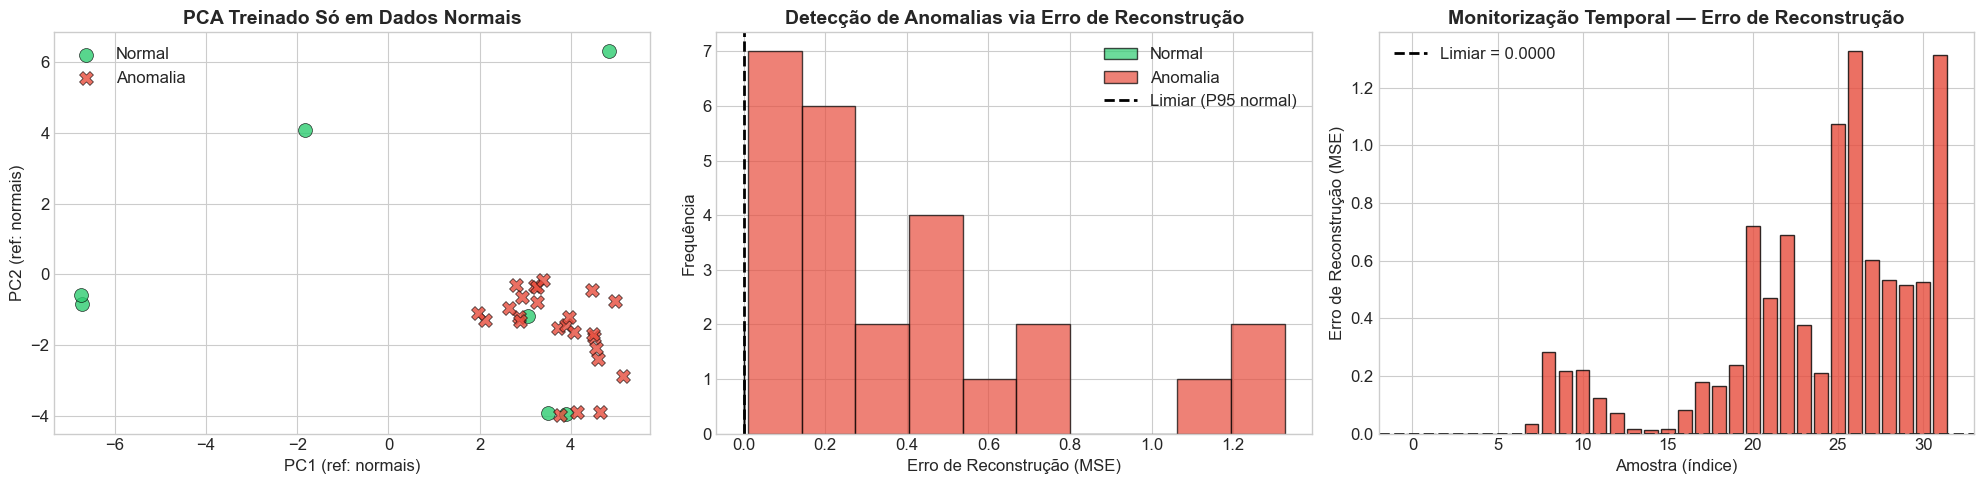

📊 Erro de Reconstrução (PCA com 7 componentes):
   Normal:  Média = 0.0000, Std = 0.0000
   Anomalia: Média = 0.4004, Std = 0.3765
   Limiar (P95 normais) = 0.0000

   Anomalias detectadas acima do limiar: 25/25

💡 O erro de reconstrução é uma abordagem elegante para detecção de anomalias!
   Dados 'estranhos' (drift ou anomalia) não são bem representados pelo PCA de referência.


In [13]:
# --- 8. Drift Temporal com PCA ---

# Treinar PCA apenas nos dados "normais" (sem erro) — modelo de referência
mask_normal = y_feat_text == 'no'
X_normal = X_scaled[mask_normal]
X_anomalo = X_scaled[~mask_normal]

# Limitar n_components ao máximo permitido para X_normal
max_components = min(X_normal.shape[0], X_normal.shape[1])
n_components_ref = min(n_95, max_components)
print(f"ℹ️ n_95={n_95}, max permitido={max_components} → usando n_components={n_components_ref}")

pca_ref = PCA(n_components=n_components_ref)
pca_ref.fit(X_normal)  # Treinado APENAS em dados normais

# Projetar ambos os conjuntos
X_normal_pca = pca_ref.transform(X_normal)
X_anomalo_pca = pca_ref.transform(X_anomalo)

# Erro de reconstrução para cada grupo
X_normal_rec = pca_ref.inverse_transform(X_normal_pca)
X_anomalo_rec = pca_ref.inverse_transform(X_anomalo_pca)

mse_normal = np.mean((X_normal - X_normal_rec) ** 2, axis=1)
mse_anomalo = np.mean((X_anomalo - X_anomalo_rec) ** 2, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Projeções PCA 2D (modelo treinado só em normais)
pca_ref_2d = PCA(n_components=2)
pca_ref_2d.fit(X_normal)
X_all_pca2d = pca_ref_2d.transform(X_scaled)

colors = [COLORS[y] for y in y_feat_text]
axes[0].scatter(X_all_pca2d[mask_normal, 0], X_all_pca2d[mask_normal, 1], 
                c=COLORS['no'], s=100, alpha=0.8, edgecolors='black', linewidths=0.5, label='Normal')
axes[0].scatter(X_all_pca2d[~mask_normal, 0], X_all_pca2d[~mask_normal, 1], 
                c=COLORS['yes'], s=100, alpha=0.8, edgecolors='black', linewidths=0.5, 
                marker='X', label='Anomalia')
axes[0].set_xlabel('PC1 (ref: normais)')
axes[0].set_ylabel('PC2 (ref: normais)')
axes[0].set_title('PCA Treinado Só em Dados Normais', fontweight='bold')
axes[0].legend()

# Plot 2: Distribuição do erro de reconstrução
axes[1].hist(mse_normal, bins=10, alpha=0.7, color=COLORS['no'], label='Normal', edgecolor='black')
axes[1].hist(mse_anomalo, bins=10, alpha=0.7, color=COLORS['yes'], label='Anomalia', edgecolor='black')
axes[1].axvline(x=np.percentile(mse_normal, 95), color='black', linestyle='--', 
                linewidth=2, label='Limiar (P95 normal)')
axes[1].set_xlabel('Erro de Reconstrução (MSE)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Detecção de Anomalias via Erro de Reconstrução', fontweight='bold')
axes[1].legend()

# Plot 3: Erro de reconstrução por amostra (série temporal simulada)
all_mse = np.concatenate([mse_normal, mse_anomalo])
all_labels = np.concatenate([['Normal'] * len(mse_normal), ['Anomalia'] * len(mse_anomalo)])
all_colors = [COLORS['no'] if l == 'Normal' else COLORS['yes'] for l in all_labels]

axes[2].bar(range(len(all_mse)), all_mse, color=all_colors, edgecolor='black', alpha=0.8)
threshold = np.percentile(mse_normal, 95)
axes[2].axhline(y=threshold, color='black', linestyle='--', linewidth=2, label=f'Limiar = {threshold:.4f}')
axes[2].set_xlabel('Amostra (índice)')
axes[2].set_ylabel('Erro de Reconstrução (MSE)')
axes[2].set_title('Monitorização Temporal — Erro de Reconstrução', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

# Estatísticas
print(f"📊 Erro de Reconstrução (PCA com {n_components_ref} componentes):")
print(f"   Normal:  Média = {np.mean(mse_normal):.4f}, Std = {np.std(mse_normal):.4f}")
print(f"   Anomalia: Média = {np.mean(mse_anomalo):.4f}, Std = {np.std(mse_anomalo):.4f}")
print(f"   Limiar (P95 normais) = {threshold:.4f}")
print(f"\n   Anomalias detectadas acima do limiar: {np.sum(mse_anomalo > threshold)}/{len(mse_anomalo)}")
print(f"\n💡 O erro de reconstrução é uma abordagem elegante para detecção de anomalias!")
print("   Dados 'estranhos' (drift ou anomalia) não são bem representados pelo PCA de referência.")

---

## 9. Aplicação nos Dados Brutos (ADXL345)

Até agora, aplicamos PCA e UMAP nas **features engenheiradas** (27 features por janela). Mas e se aplicarmos diretamente nos **dados brutos** do acelerómetro?

| Aspecto | Features (32×27) | Dados Brutos (1082×3) |
|---------|------------------|----------------------|
| **Dimensão** | 27 features por janela | 3 eixos (X, Y, Z) |
| **Amostras** | 32 janelas | 1082 leituras |
| **Informação** | Resumida / estatística | Bruta / temporal |
| **PCA ajuda?** | Sim — muita redundância | Talvez — 3D já é baixo |

> **💡 Ponto pedagógico:** PCA em 3 dimensões pode parecer "pouco útil", mas demonstra o conceito claramente e permite visualizar a concentração de variância.

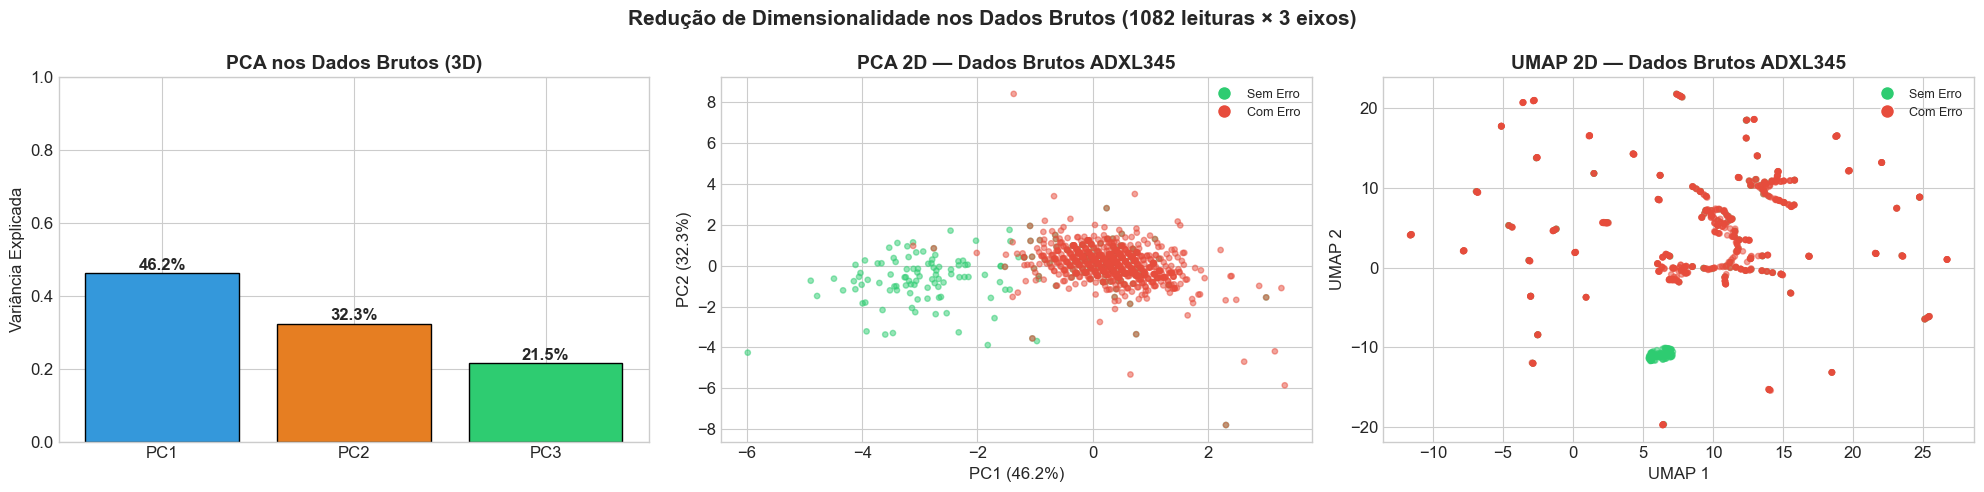

📊 Loadings do PCA nos Dados Brutos:
   PC1 (46.2%): X=-0.278 | Y=+0.685 | Z=+0.673
   PC2 (32.3%): X=+0.958 | Y=+0.149 | Z=+0.244
   PC3 (21.5%): X=+0.067 | Y=+0.713 | Z=-0.698

💡 Nos dados brutos (3D), PCA tem papel limitado — a dimensionalidade já é baixa.
   A verdadeira utilidade está nas features engenheiradas (27D → 5-7D).


In [14]:
# --- 9. PCA e UMAP nos Dados Brutos ADXL345 ---

# Preparar dados brutos
raw_cols = ['X-direction', 'Y-direction', 'Z-direction']
X_raw = df_raw[raw_cols].values
y_raw_text = df_raw['Error_found'].values
y_raw_numeric = np.array([0 if y == 'no' else 1 for y in y_raw_text])

scaler_raw = StandardScaler()
X_raw_scaled = scaler_raw.fit_transform(X_raw)

# PCA nos dados brutos (3 dimensões → todas as componentes possíveis)
pca_raw = PCA()
X_raw_pca = pca_raw.fit_transform(X_raw_scaled)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Variância explicada (todos os 3 componentes)
axes[0].bar(['PC1', 'PC2', 'PC3'], pca_raw.explained_variance_ratio_, 
            color=['#3498db', '#e67e22', '#2ecc71'], edgecolor='black')
for i, v in enumerate(pca_raw.explained_variance_ratio_):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')
axes[0].set_ylabel('Variância Explicada')
axes[0].set_title('PCA nos Dados Brutos (3D)', fontweight='bold')
axes[0].set_ylim(0, 1)

# Plot 2: PCA 2D nos dados brutos
colors_raw = [COLORS.get(y, '#999999') for y in y_raw_text]
axes[1].scatter(X_raw_pca[:, 0], X_raw_pca[:, 1], c=colors_raw, s=15, alpha=0.5)
axes[1].set_xlabel(f'PC1 ({pca_raw.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_raw.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('PCA 2D — Dados Brutos ADXL345', fontweight='bold')

# Plot 3: UMAP nos dados brutos (se disponível)
if HAS_UMAP:
    reducer_raw = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    X_raw_umap = reducer_raw.fit_transform(X_raw_scaled)
    axes[2].scatter(X_raw_umap[:, 0], X_raw_umap[:, 1], c=colors_raw, s=15, alpha=0.5)
    axes[2].set_xlabel('UMAP 1')
    axes[2].set_ylabel('UMAP 2')
    axes[2].set_title('UMAP 2D — Dados Brutos ADXL345', fontweight='bold')
else:
    axes[2].text(0.5, 0.5, 'UMAP não\ndisponível', ha='center', va='center', 
                 fontsize=16, transform=axes[2].transAxes)
    axes[2].set_title('UMAP 2D — Não disponível', fontweight='bold')

# Legenda
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS['no'], markersize=10, label='Sem Erro'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS['yes'], markersize=10, label='Com Erro')
]
for ax in axes[1:]:
    ax.legend(handles=legend_elements, fontsize=9)

plt.suptitle('Redução de Dimensionalidade nos Dados Brutos (1082 leituras × 3 eixos)', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Loadings do PCA nos dados brutos
raw_labels = ['X', 'Y', 'Z']
print("📊 Loadings do PCA nos Dados Brutos:")
for i in range(3):
    loadings_raw = pca_raw.components_[i]
    print(f"   PC{i+1} ({pca_raw.explained_variance_ratio_[i]:.1%}): " +
          " | ".join([f"{raw_labels[j]}={loadings_raw[j]:+.3f}" for j in range(3)]))

print(f"\n💡 Nos dados brutos (3D), PCA tem papel limitado — a dimensionalidade já é baixa.")
print("   A verdadeira utilidade está nas features engenheiradas (27D → 5-7D).")

---

## 10. Exportação dos Artefatos (.joblib)

Seguindo o padrão das aulas anteriores, vamos exportar todos os artefatos treinados nesta aula:

| Artefato | Conteúdo | Uso em Produção |
|----------|----------|-----------------|
| `pca_model.joblib` | PCA treinado com N componentes ideais | Transformar novos dados |
| `pca_reference.joblib` | PCA treinado em dados normais (para drift) | Detecção de anomalias |
| `scaler_features.joblib` | StandardScaler das features | Pré-processar antes do PCA |
| `reducao_config.joblib` | Configurações e limiares | Thresholds de anomalia |

> **📁 Destino:** `modelos_exportados/reducao_dimensionalidade/`

In [15]:
# --- 10. Exportação dos Artefatos ---

export_dir = Path("modelos_exportados/reducao_dimensionalidade")
export_dir.mkdir(parents=True, exist_ok=True)

# 1) PCA treinado para pré-processamento (todas as amostras, n_95 componentes)
pca_export = PCA(n_components=n_95)
pca_export.fit(X_scaled)
joblib.dump(pca_export, export_dir / "pca_model.joblib")

# 2) PCA de referência (treinado só em normais, para detecção de drift/anomalia)
joblib.dump(pca_ref, export_dir / "pca_reference.joblib")

# 3) Scaler das features engenheiradas
joblib.dump(scaler, export_dir / "scaler_features.joblib")

# 4) Configurações e limiares
config = {
    'n_componentes_95': int(n_95),
    'n_componentes_90': int(n_90),
    'n_componentes_80': int(n_80),
    'feature_cols': feature_cols,
    'variancia_explicada_95': float(sum(pca_export.explained_variance_ratio_)),
    'threshold_anomalia_mse': float(threshold),
    'n_amostras_treino': int(X_scaled.shape[0]),
    'n_features_original': int(X_scaled.shape[1]),
    'aula': 'Aula_08_Reducao_Dimensionalidade'
}
joblib.dump(config, export_dir / "reducao_config.joblib")

print("=" * 60)
print("📦 ARTEFATOS EXPORTADOS")
print("=" * 60)
for f in sorted(export_dir.glob("*.joblib")):
    size_kb = f.stat().st_size / 1024
    print(f"   ✅ {f.name} ({size_kb:.1f} KB)")

print(f"\n📁 Diretório: {export_dir.resolve()}")
print(f"\n📋 Configurações salvas:")
for key, val in config.items():
    if key != 'feature_cols':
        print(f"   {key}: {val}")
    else:
        print(f"   {key}: [{len(val)} features]")

📦 ARTEFATOS EXPORTADOS
   ✅ pca_model.joblib (3.0 KB)
   ✅ pca_reference.joblib (2.7 KB)
   ✅ reducao_config.joblib (0.5 KB)
   ✅ scaler_features.joblib (1.2 KB)

📁 Diretório: C:\Users\paulo\Downloads\UC - Reconhecimento de Padrões\Notebooks\modelos_exportados\reducao_dimensionalidade

📋 Configurações salvas:
   n_componentes_95: 8
   n_componentes_90: 7
   n_componentes_80: 5
   feature_cols: [27 features]
   variancia_explicada_95: 0.9589872763569046
   threshold_anomalia_mse: 3.4549221161176154e-30
   n_amostras_treino: 32
   n_features_original: 27
   aula: Aula_08_Reducao_Dimensionalidade


---

## 11. Importação e Predição em "Novo Sistema"

Simulamos aqui um cenário real: um **novo sistema** que só tem acesso aos artefatos exportados (`.joblib`) e recebe dados novos de vibração. Este padrão é essencial para **deployment em produção**.

### Pipeline de Produção:
1. **Carregar** scaler, PCA, e configurações
2. **Receber** novas leituras brutas do sensor
3. **Padronizar** com o scaler carregado
4. **Transformar** com o PCA carregado
5. **Verificar** erro de reconstrução (anomalia/drift)
6. **Passar** dados reduzidos para classificador ou SBC (Aula 9)

In [16]:
# --- 11. Simulação de Novo Sistema ---

print("=" * 60)
print("🔄 SIMULAÇÃO: NOVO SISTEMA DE PRODUÇÃO")
print("=" * 60)

# 1) Carregar artefatos (como se fosse outro programa)
load_dir = Path("modelos_exportados/reducao_dimensionalidade")
pca_loaded = joblib.load(load_dir / "pca_model.joblib")
pca_ref_loaded = joblib.load(load_dir / "pca_reference.joblib")
scaler_loaded = joblib.load(load_dir / "scaler_features.joblib")
config_loaded = joblib.load(load_dir / "reducao_config.joblib")

print(f"\n✅ Artefatos carregados de: {load_dir}")
print(f"   PCA: {pca_loaded.n_components} componentes ({config_loaded['variancia_explicada_95']:.1%} variância)")
print(f"   Threshold anomalia: {config_loaded['threshold_anomalia_mse']:.4f}")

# 2) Simular novas leituras (usando amostras reais como exemplo)
print(f"\n📥 Simulação de novos dados chegando...")
np.random.seed(42)

# Amostra normal (pegar uma real)
nova_normal = X_feat[y_feat_text == 'no'][0].reshape(1, -1)
# Amostra com erro (pegar uma real)
nova_erro = X_feat[y_feat_text == 'yes'][0].reshape(1, -1)
# Amostra "muito anómala" (ruído extremo)
nova_anomala = nova_normal + np.random.randn(1, X_feat.shape[1]) * 5

novas_amostras = {
    'Normal (real)': nova_normal,
    'Com Erro (real)': nova_erro,
    'Anomalia Extrema (simulada)': nova_anomala
}

# 3) Pipeline de produção para cada amostra
for nome, amostra in novas_amostras.items():
    print(f"\n{'─' * 50}")
    print(f"📊 Processando: {nome}")
    
    # Passo 1: Padronizar
    amostra_scaled = scaler_loaded.transform(amostra)
    
    # Passo 2: Transformar com PCA
    amostra_pca = pca_loaded.transform(amostra_scaled)
    
    # Passo 3: Verificar erro de reconstrução
    amostra_rec = pca_ref_loaded.inverse_transform(pca_ref_loaded.transform(amostra_scaled))
    mse = np.mean((amostra_scaled - amostra_rec) ** 2)
    
    # Passo 4: Classificar como normal/anomalia
    is_anomaly = mse > config_loaded['threshold_anomalia_mse']
    status = "🔴 ANOMALIA" if is_anomaly else "🟢 NORMAL"
    
    print(f"   Dimensões: {amostra.shape[1]}D → {amostra_pca.shape[1]}D")
    print(f"   Erro de reconstrução: {mse:.4f} (limiar: {config_loaded['threshold_anomalia_mse']:.4f})")
    print(f"   Status: {status}")
    print(f"   Coordenadas PCA: [{', '.join([f'{v:.2f}' for v in amostra_pca[0][:5]])}...]")

print(f"\n{'=' * 60}")
print("✅ Pipeline de produção funcional!")
print("   → Próximo passo: integrar com classificador (Aula 6) ou SBC (Aula 9)")

🔄 SIMULAÇÃO: NOVO SISTEMA DE PRODUÇÃO

✅ Artefatos carregados de: modelos_exportados\reducao_dimensionalidade
   PCA: 8 componentes (95.9% variância)
   Threshold anomalia: 0.0000

📥 Simulação de novos dados chegando...

──────────────────────────────────────────────────
📊 Processando: Normal (real)
   Dimensões: 27D → 8D
   Erro de reconstrução: 0.0000 (limiar: 0.0000)
   Status: 🟢 NORMAL
   Coordenadas PCA: [-9.68, 2.23, -1.58, 0.17, -0.77...]

──────────────────────────────────────────────────
📊 Processando: Com Erro (real)
   Dimensões: 27D → 8D
   Erro de reconstrução: 0.0322 (limiar: 0.0000)
   Status: 🔴 ANOMALIA
   Coordenadas PCA: [-0.26, -1.27, -0.70, -0.73, 1.01...]

──────────────────────────────────────────────────
📊 Processando: Anomalia Extrema (simulada)
   Dimensões: 27D → 8D
   Erro de reconstrução: 572.6871 (limiar: 0.0000)
   Status: 🔴 ANOMALIA
   Coordenadas PCA: [-22.05, 55.31, 1.08, 4.78, 4.97...]

✅ Pipeline de produção funcional!
   → Próximo passo: integrar com

---

## 12. Resumo e Conclusões

### 📋 O Que Aprendemos Nesta Aula

| Tópico | Conceito-Chave | Aplicação Prática |
|--------|---------------|-------------------|
| **Maldição da Dimensionalidade** | Muitas features + poucas amostras = problemas | 32 amostras × 27 features → reduzir! |
| **PCA** | Projeção linear que maximiza variância | Compressão: 27D → 5-7D com ≥95% variância |
| **Variância Explicada** | Critério para escolher N componentes | Scree plot + regra dos 95% |
| **Loadings** | Quais features contribuem para cada PC | Interpretar componentes abstratas |
| **Reconstrução** | Inverter PCA para recuperar dados originais | Detecção de anomalias via erro |
| **UMAP** | Redução não-linear que preserva vizinhança | Visualização superior de clusters |
| **Hiperparâmetros UMAP** | n_neighbors e min_dist controlam o resultado | Exploração visual necessária |
| **PCA como pré-processamento** | Reduzir antes de clustering/classificação | Menos overfitting, treino mais rápido |
| **Detecção de drift** | Erro de reconstrução alto = dados "estranhos" | Monitorização em produção |

### 🔗 Conexão com as Aulas Anteriores e Seguinte

```
Aula 5 (Features) ─── dados ───→ Aula 6 (Classificação)
       │                               │
       │                               ▼
       └─── dados ───→ Aula 7 (Clustering)
                              │
                              ▼
                    Aula 8 (Redução) ← HOJE
                              │
                              ▼
                    Aula 9 (Consolidação/SBC)
                    • PCA como pré-processamento
                    • Detecção de drift com erro de reconstrução
                    • Integração com regras simbólicas
```

### 🎯 Para a Aula 9 (Consolidação)

Na próxima aula, vamos **integrar tudo** num pipeline completo usando um Sistema Baseado em Conhecimento (SBC):
1. **Dados brutos** → Feature Engineering (Aula 5)
2. **Features** → PCA Redução (Aula 8) *← NOVO!*
3. **Features reduzidas** → Classificação (Aula 6) + Clustering (Aula 7)
4. **Resultados** → Regras SBC para decisão final

Os artefatos exportados desta aula serão carregados na Aula 9!

### 💡 Pontos-Chave para Levar

1. **PCA para pipeline, UMAP para visualização** — não são concorrentes, são complementares
2. **Standardização é obrigatória** antes de PCA e UMAP — features em escalas diferentes distorcem resultados
3. **O número de componentes importa** — 95% é bom default, mas validar com o modelo downstream
4. **Erro de reconstrução** é uma ferramenta poderosa para monitorização em produção
5. **Com poucos dados** (como o nosso caso), redução de dimensionalidade é quase sempre benéfica